# Sentinela Verde — base de treino do modelo de impacto

**Projeto:** monitoramento geoespacial de impacto ambiental/territorial no entorno de data centers — MBA Engenharia de Dados, Mackenzie.

Este notebook apresenta a **frente de apoio ao modelo de impacto** (do Guilherme): dado um data center, montar um painel de cobertura do solo **antes, durante e depois da obra**, com um **grupo de controle pareado** para separar o que mudou por causa do empreendimento do que mudaria na região de qualquer jeito.

Não é o notebook do classificador — esse é o [`00_demo_preview.ipynb`](00_demo_preview.ipynb), que mostra como o modelo `rf_v1.0-tuned` foi treinado e avaliado. Aqui o classificador é **usado**, não construído: ele roda sobre pontos novos e a saída vira feature.

**O que foi entregue:** um painel de 204 linhas (15 pares × 2 pontos × 5 a 8 anos) com área e proporção das 5 classes de cobertura, em `modelo-impacto/processed/painel_impacto_area_por_classe.csv`.

Como o `00_demo_preview`, este notebook **consome** artefatos já gerados pelos scripts de `modelo-impacto/scripts/` — não recalcula nada pesado. Cada figura tem o script que a produz indicado no texto.

## Setup

In [1]:
from pathlib import Path
import sys


def _find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for candidate in [p, *p.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("não encontrei a raiz do repositório (pyproject.toml) a partir do cwd do notebook")


REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT / "src"))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

IMPACTO_DIR = REPO_ROOT / "modelo-impacto"
CONTROLES_DIR = IMPACTO_DIR / "raw" / "controles-rf"
FIGURAS_DIR = CONTROLES_DIR / "figuras"

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

reconciliacao = pd.read_csv(CONTROLES_DIR / "reconciliacao_datacenters.csv")
diagnostico = pd.read_csv(CONTROLES_DIR / "diagnostico_candidatos_guilherme.csv")
candidatos = pd.read_csv(CONTROLES_DIR / "candidatos_avaliados_rf.csv")
pareamento = pd.read_csv(CONTROLES_DIR / "pareamento_controle_rf.csv")
painel = pd.read_csv(IMPACTO_DIR / "processed" / "painel_impacto_area_por_classe.csv")

print(f"pareamento: {len(pareamento)} campi | painel: {len(painel)} linhas")

pareamento: 15 campi | painel: 204 linhas


## 1. O ponto de partida — e a primeira surpresa

A entrada foram dois CSVs do Guilherme: **12 data centers** (`datacenter_filtrado.csv`) e **6 candidatos a ponto de controle para cada um** (`datacenter_expandido_6_pontos.csv`, 72 pontos).

Antes de rodar qualquer coisa, medimos os 12 pontos contra a lista de sites que este repositório já tinha validado com uma cascata de 5 camadas (`config/sites.geojson`). **Todos os 12 estão a menos de 1,03 km de um site já validado** — e, mais importante, vários são o **mesmo lugar**.

In [2]:
resumo_campi = (
    reconciliacao.groupby(["site_id", "municipio_repo", "uf_repo", "ano_inicio_obra_repo"])
    .agg(predios=("id_datacenter", "count"),
         dist_max_km=("distancia_ao_site_km", "max"))
    .reset_index()
    .sort_values("predios", ascending=False)
)
print(f"{len(reconciliacao)} id_datacenter  ->  {resumo_campi.site_id.nunique()} campi distintos")
resumo_campi

12 id_datacenter  ->  8 campi distintos


,site_id,municipio_repo,uf_repo,ano_inicio_obra_repo,predios,dist_max_km
0,ascenty-hortolandia,Hortolândia,SP,2018,4,0.206
2,ascenty-osasco,Osasco,SP,2020,2,0.331
1,ascenty-jundiai,Jundiaí,SP,2019,1,0.184
3,ascenty-paulinia,Paulínia,SP,2019,1,0.079
4,ascenty-sumare,Sumaré,SP,2017,1,1.025
5,equinix-santana-parnaiba,Santana de Parnaíba,SP,2020,1,0.486
6,scala-sgigsm01,São João de Meriti,RJ,2022,1,0.458
7,scala-spoapa01,Porto Alegre,RS,2023,1,0.018


Os 4 prédios de Hortolândia estão a **56–193 m** um do outro; os 2 de Osasco, a **164 m**. O buffer de análise do classificador tem **5 km de raio**. Nessa escala eles não são observações independentes — são o mesmo recorte de terreno, medido quatro vezes.

Medir por prédio inflaria a amostra sem acrescentar informação: Hortolândia entraria no modelo de impacto com peso 4 e Porto Alegre com peso 1, sem que isso fosse decisão de ninguém. **A medição passou a ser por campus**, e o painel carrega a coluna `ids_datacenter` para o Guilherme dar o join pela chave dele.

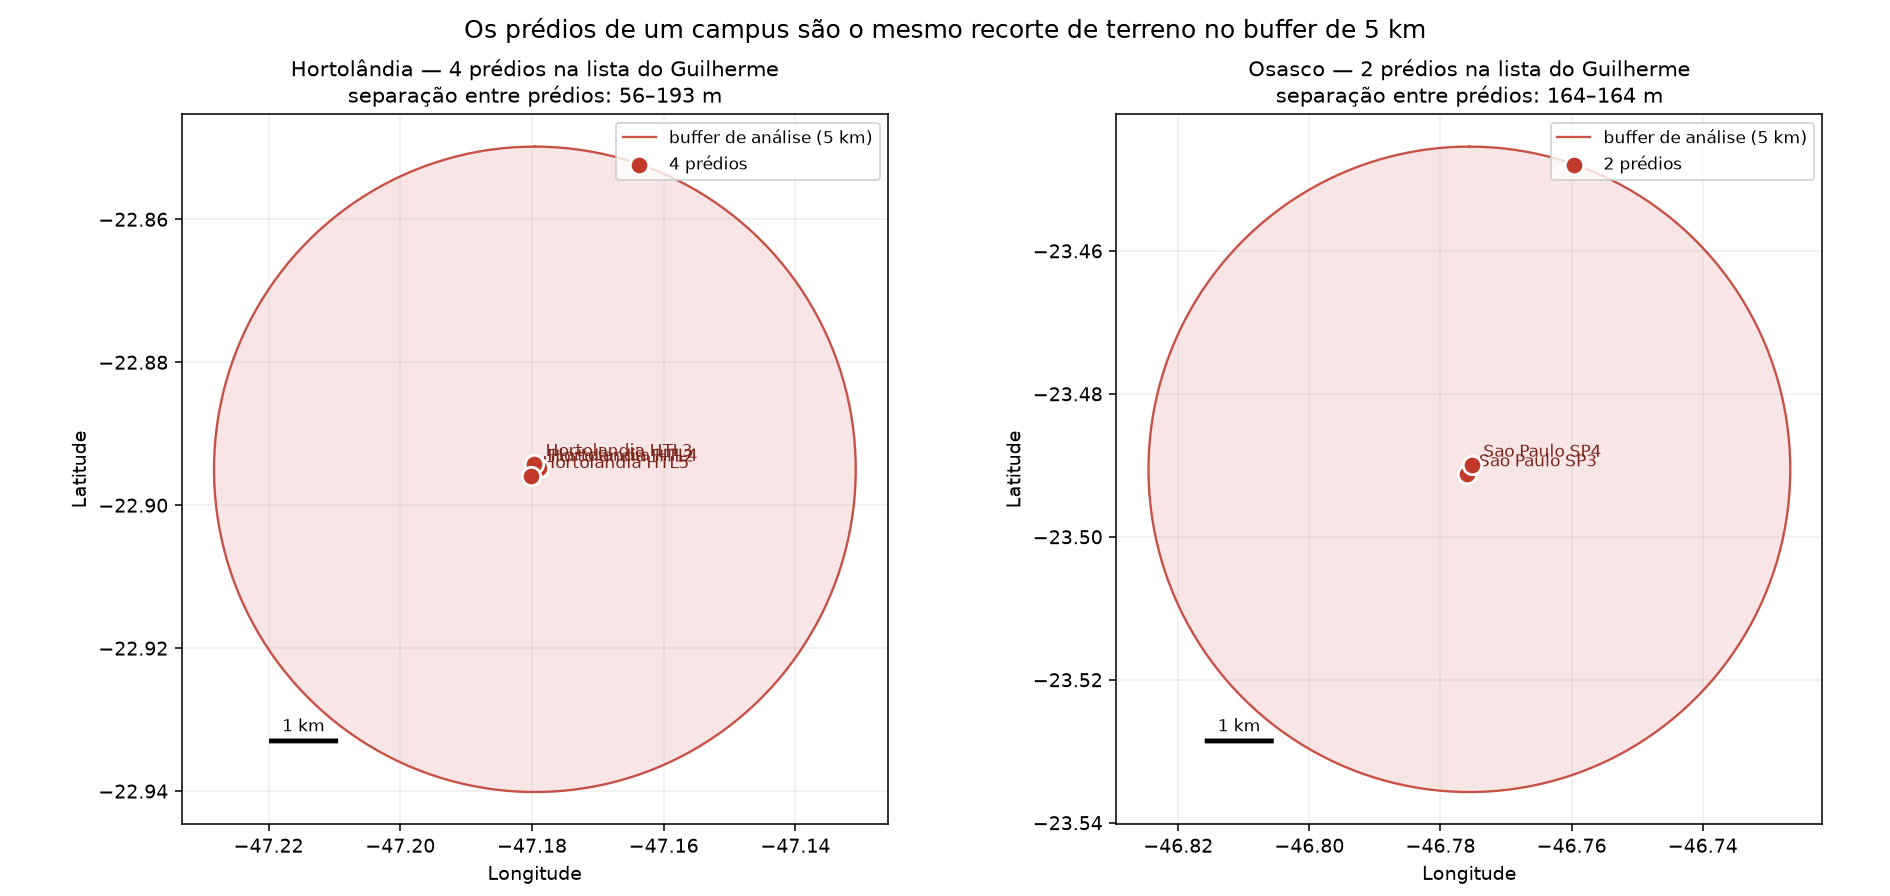

In [3]:
display(Image(filename=str(FIGURAS_DIR / "fig_01_campi_predios.png")))

**Consequência boa:** como todos já eram sites validados, o `ano_inicio_obra` de cada um já estava pesquisado e conferido — o passo de "identificar o ano de início da obra" saiu de graça.

Vale registrar uma distinção que o CSV de origem não faz: `ano_operacional` **não é** o ano em que a obra começou. Nos 15 sites validados, a defasagem entre obra e operação é de 0 ano em 7 casos, 1 ano em 4 e 2 anos em 2. Usar um pelo outro deslocaria a janela "antes/depois" em até 2 anos — justamente na direção que borra o efeito que se quer medir.

## 2. Por que a tabela de candidatos a controle não pôde ser usada

O gerador do Guilherme escolhe um **município socioeconomicamente similar**, mede a distância do data center até o centróide do **próprio** município, e monta um **hexágono de 6 pontos com esse mesmo raio** em volta do município similar. A ideia é boa — replicar "a que distância do centro urbano o empreendimento fica" num município comparável.

O problema é que o passo final **não checa se o lugar onde os 6 pontos caem já tem um data center do estudo dentro**.

In [4]:
por_campus = (
    diagnostico.groupby("site_id")
    .agg(candidatos=("ponto_num", "count"),
         contaminados=("contaminado", "sum"),
         dist_min_ao_proprio_dc=("dist_ao_proprio_dc_km", "min"),
         dist_max_ao_proprio_dc=("dist_ao_proprio_dc_km", "max"),
         tratamento_mais_proximo_km=("dist_ao_tratamento_mais_proximo_km", "min"))
    .reset_index()
    .sort_values("contaminados", ascending=False)
)
print(f"{int(diagnostico.contaminado.sum())} de {len(diagnostico)} candidatos a menos de 10 km "
      f"de um data center do estudo — buffers de 5 km sobrepostos")
por_campus

14 de 72 candidatos a menos de 10 km de um data center do estudo — buffers de 5 km sobrepostos


,site_id,candidatos,contaminados,dist_min_ao_proprio_dc,dist_max_ao_proprio_dc,tratamento_mais_proximo_km
6,scala-sgigsm01,6,6,363.52,366.87,2.18
3,ascenty-paulinia,6,4,33.18,41.15,2.40
2,ascenty-osasco,12,4,30.97,40.19,5.31
1,ascenty-jundiai,6,0,11.66,29.70,11.60
0,ascenty-hortolandia,24,0,126.44,138.19,79.83
4,ascenty-sumare,6,0,24.92,36.01,15.60
5,equinix-santana-parnaiba,6,0,161.11,172.10,132.35
7,scala-spoapa01,6,0,537.33,545.62,323.19


Um ponto de controle dentro do raio de influência de um data center é **tratamento disfarçado de controle**: o efeito medido encolhe na direção de zero, e nada no resultado indica que houve problema. É o erro mais grave possível neste desenho.

Os três piores casos:

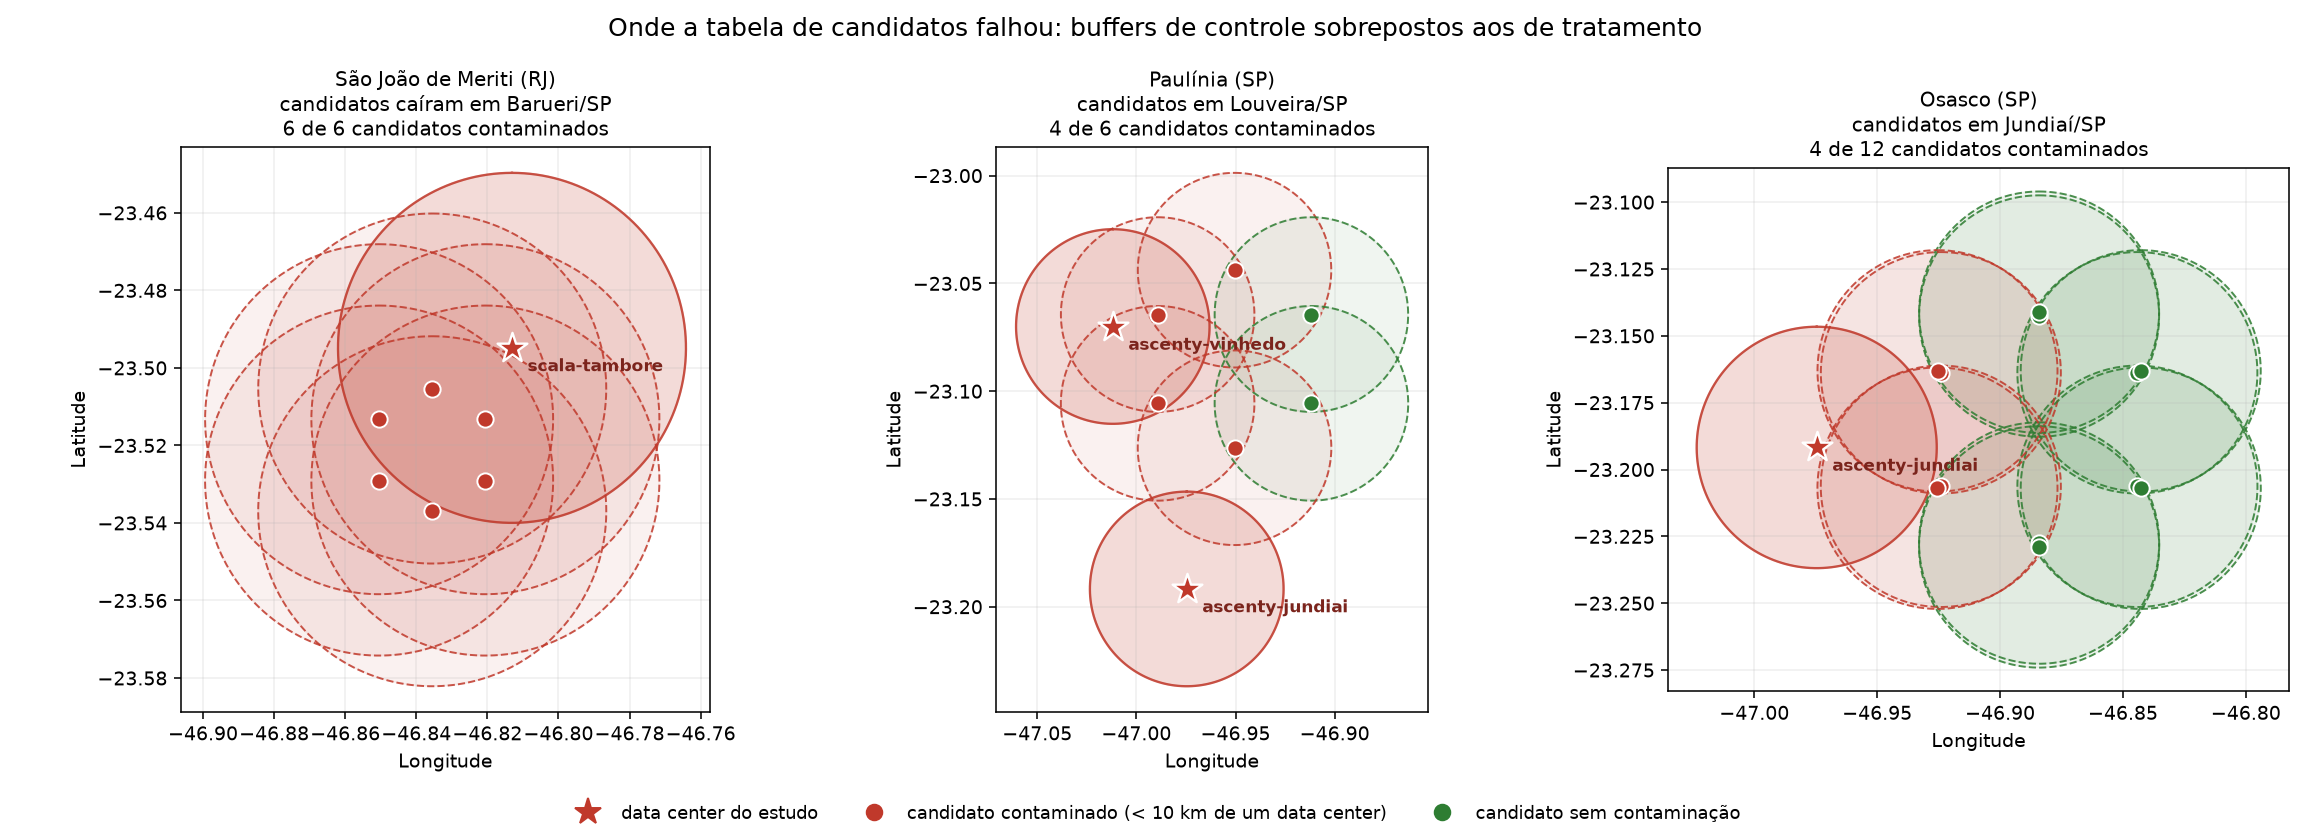

In [5]:
display(Image(filename=str(FIGURAS_DIR / "fig_02_candidatos_contaminados.png")))

Além da contaminação, dois problemas estruturais:

**Os 6 candidatos de um data center não são 6 amostras independentes.** O raio do hexágono varia de 1,76 a 9,14 km, e o buffer de análise tem 5 km — então os buffers de candidatos vizinhos se sobrepõem de 3% (Jundiaí) a **78% (São João de Meriti)**. Escolher "o melhor dos 6" ali é escolher entre 6 recortes que compartilham quase 80% da mesma área.

**Três campi ficaram em outro estado.** Porto Alegre foi pareado com **Curitiba** (540 km) — sai do **Pampa** e entra na **Mata Atlântica**. Vegetação de base, regime de chuva e sazonalidade são outros; o classificador acusaria diferença que não tem nada a ver com o data center.

> O diagnóstico numérico completo, escrito para o Guilherme, está em [`DIAGNOSTICO-TABELA-GUILHERME.md`](../modelo-impacto/raw/controles-rf/DIAGNOSTICO-TABELA-GUILHERME.md). Ele fecha sugerindo os dois checks baratos que faltam no gerador: rejeitar candidato a menos de 10 km de qualquer data center conhecido, e exigir raio de hexágono ≥ 10 km.

## 3. Como os controles foram gerados

Reaproveitamos o desenho de grupo de controle que este repositório já tinha (`docs/tarefas/SV-29-grupo-controle-pareado.md`), que resolve exatamente os problemas acima:

- **anel de 15 a 40 km** do data center — longe o bastante para sair do raio de influência, perto o bastante para manter regime de licenciamento, pressão de expansão urbana e regime de chuva comparáveis;
- **mesmo município ou mesma microrregião do IBGE** — o que preserva bioma e clima sem cruzar meio país;
- **checagem de contaminação explícita** contra 38 pontos, incluindo os data centers **rejeitados** do estudo (são justamente lugares onde há data center e que não entraram na amostra);
- **grade de 7 raios × 24 azimutes**, embaralhada por um gerador determinístico e independente por site (seed 42 + hash do `site_id`).

A escolha final entre os candidatos válidos é o que muda nesta rodada: em vez do MapBiomas, quem decide é a **saída do classificador** — área por classe num buffer de 5 km, no ano anterior ao início da obra, escolhendo o candidato de menor distância L1.

### O funil, e o que ele custa

Rodar o classificador em todos os ~20 candidatos válidos de cada campus seria ~300 pontos e quase 2 h de chamadas de rede encadeadas (~23 s por ponto: download do composto, 7 índices, inferência). O desenho é em funil: o **MapBiomas pré-ranqueia** (consulta server-side, de graça) e os **5 melhores** passam pelo classificador, que decide.

**O custo assumido:** se o melhor candidato pelo classificador estivesse fora do top-5 do MapBiomas, ele não seria avaliado. Isso é mensurável — e foi medido:

In [6]:
d = candidatos.dropna(subset=["l1_mapbiomas", "l1_rf"])
rho = d[["l1_mapbiomas", "l1_rf"]].corr(method="spearman").iloc[0, 1]
concordou = sum(
    g.loc[g.l1_mapbiomas.idxmin(), "site_id_controle"] == g.loc[g.l1_rf.idxmin(), "site_id_controle"]
    for _, g in d.groupby("site_id")
)
print(f"finalistas avaliados pelo classificador: {len(d)}")
print(f"correlação de Spearman entre os dois critérios: {rho:.3f}")
print(f"campi em que MapBiomas e classificador escolheriam o MESMO controle: {concordou} de {d.site_id.nunique()}")

finalistas avaliados pelo classificador: 71
correlação de Spearman entre os dois critérios: 0.932
campi em que MapBiomas e classificador escolheriam o MESMO controle: 12 de 15


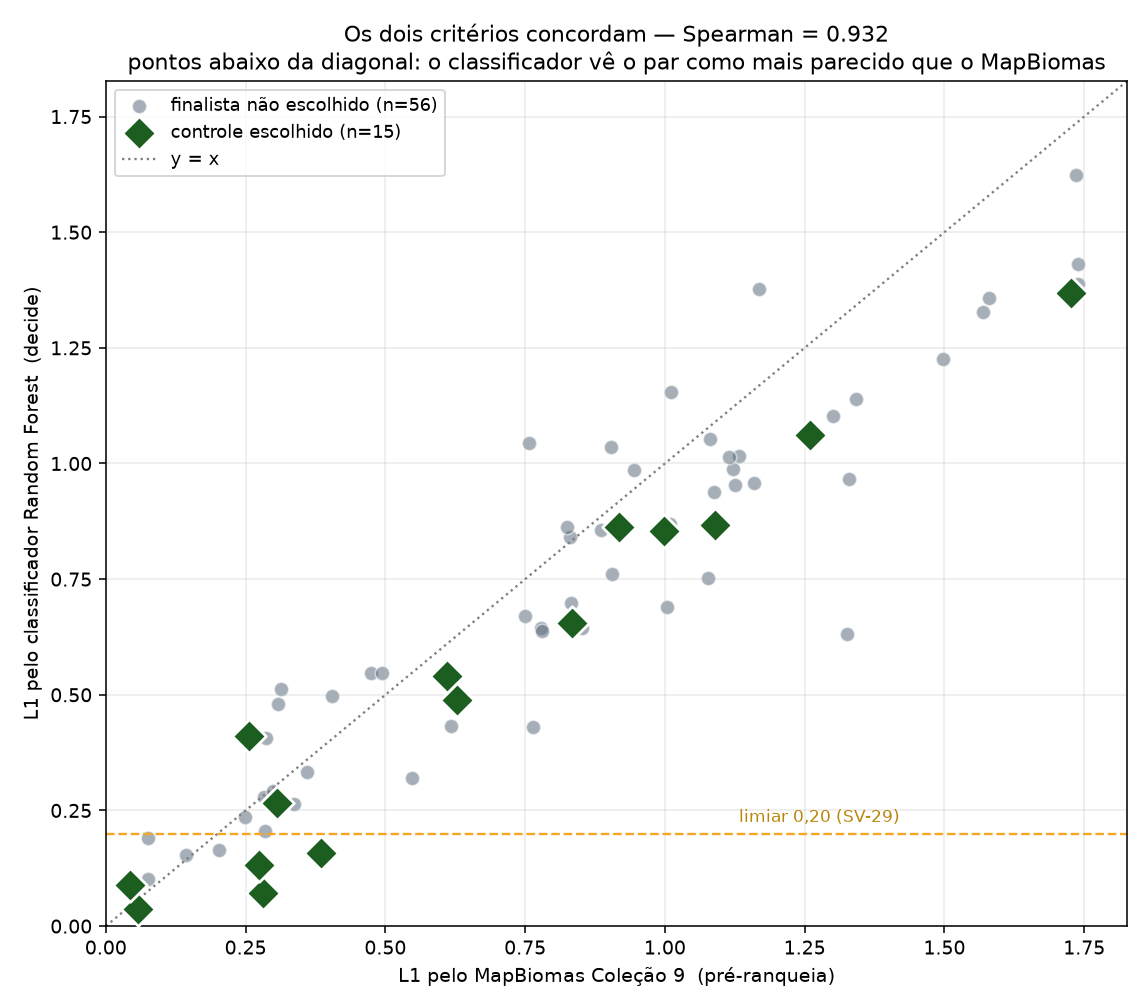

In [7]:
display(Image(filename=str(FIGURAS_DIR / "fig_03_funil_mapbiomas_rf.png")))

Correlação de 0,93 e mesmo vencedor em 12 de 15 campi: o pré-filtro raramente descarta o candidato que o classificador escolheria. O custo é real, mas pequeno — e está publicado em `candidatos_avaliados_rf.csv`, com os dois L1 lado a lado, para quem quiser conferir.

Note que **quase todos os pontos caem abaixo da diagonal**: o classificador vê os pares como mais parecidos do que o MapBiomas os vê. Isso volta a importar na seção 7.

## 4. O pareamento — 15 pares

A amostra foi ampliada de 8 para **15 campi**: os 8 da lista do Guilherme mais 7 sites que já estavam validados aqui e ficaram de fora dela. Só `odata-hortolandia` ficou fora, por não ter `ano_inicio_obra` em nenhuma fonte — sem ano de obra não há janela temporal para definir "1 ano antes".

In [8]:
tabela_pares = pareamento[[
    "site_id", "municipio", "uf", "ano_inicio_obra", "site_id_controle",
    "dist_tratamento_controle_km", "l1_rf", "l1_mapbiomas", "qualidade", "sensor",
]].sort_values("l1_rf")
print("distribuição de qualidade:", pareamento.qualidade.value_counts().to_dict())
tabela_pares

distribuição de qualidade: {'ruim': 10, 'bom': 3, 'aceitavel': 2}


,site_id,municipio,uf,ano_inicio_obra,site_id_controle,dist_tratamento_controle_km,l1_rf,l1_mapbiomas,qualidade,sensor
1,ascenty-hortolandia,Hortolândia,SP,2018,ctrl-ascenty-hortolandia-p01,16.0,0.036282,0.056711,bom,landsat
5,ascenty-paulinia,Paulínia,SP,2019,ctrl-ascenty-paulinia-p02,20.0,0.072125,0.281958,bom,landsat
2,ascenty-jundiai,Jundiaí,SP,2019,ctrl-ascenty-jundiai-p01,24.0,0.088258,0.043819,bom,landsat
7,ascenty-vinhedo,Vinhedo,SP,2019,ctrl-ascenty-vinhedo-p02,28.0,0.131596,0.273312,aceitavel,landsat
0,angonap-fortaleza,Fortaleza,CE,2017,ctrl-angonap-fortaleza-p01,16.0,0.157896,0.384545,aceitavel,landsat
4,ascenty-osasco,Osasco,SP,2020,ctrl-ascenty-osasco-p01,16.0,0.265934,0.305542,ruim,landsat
6,ascenty-sumare,Sumaré,SP,2017,ctrl-ascenty-sumare-p01,28.0,0.411088,0.256018,ruim,landsat
13,scala-spoapa01,Porto Alegre,RS,2023,ctrl-scala-spoapa01-p01,20.0,0.489003,0.628893,ruim,s2
9,equinix-santana-parnaiba,Santana de Parnaíba,SP,2020,ctrl-equinix-santana-parnaiba-p01,16.0,0.541542,0.610836,ruim,landsat
11,hostdime-joao-pessoa,João Pessoa,PB,2017,ctrl-hostdime-joao-pessoa-p01,16.0,0.655163,0.832959,ruim,landsat


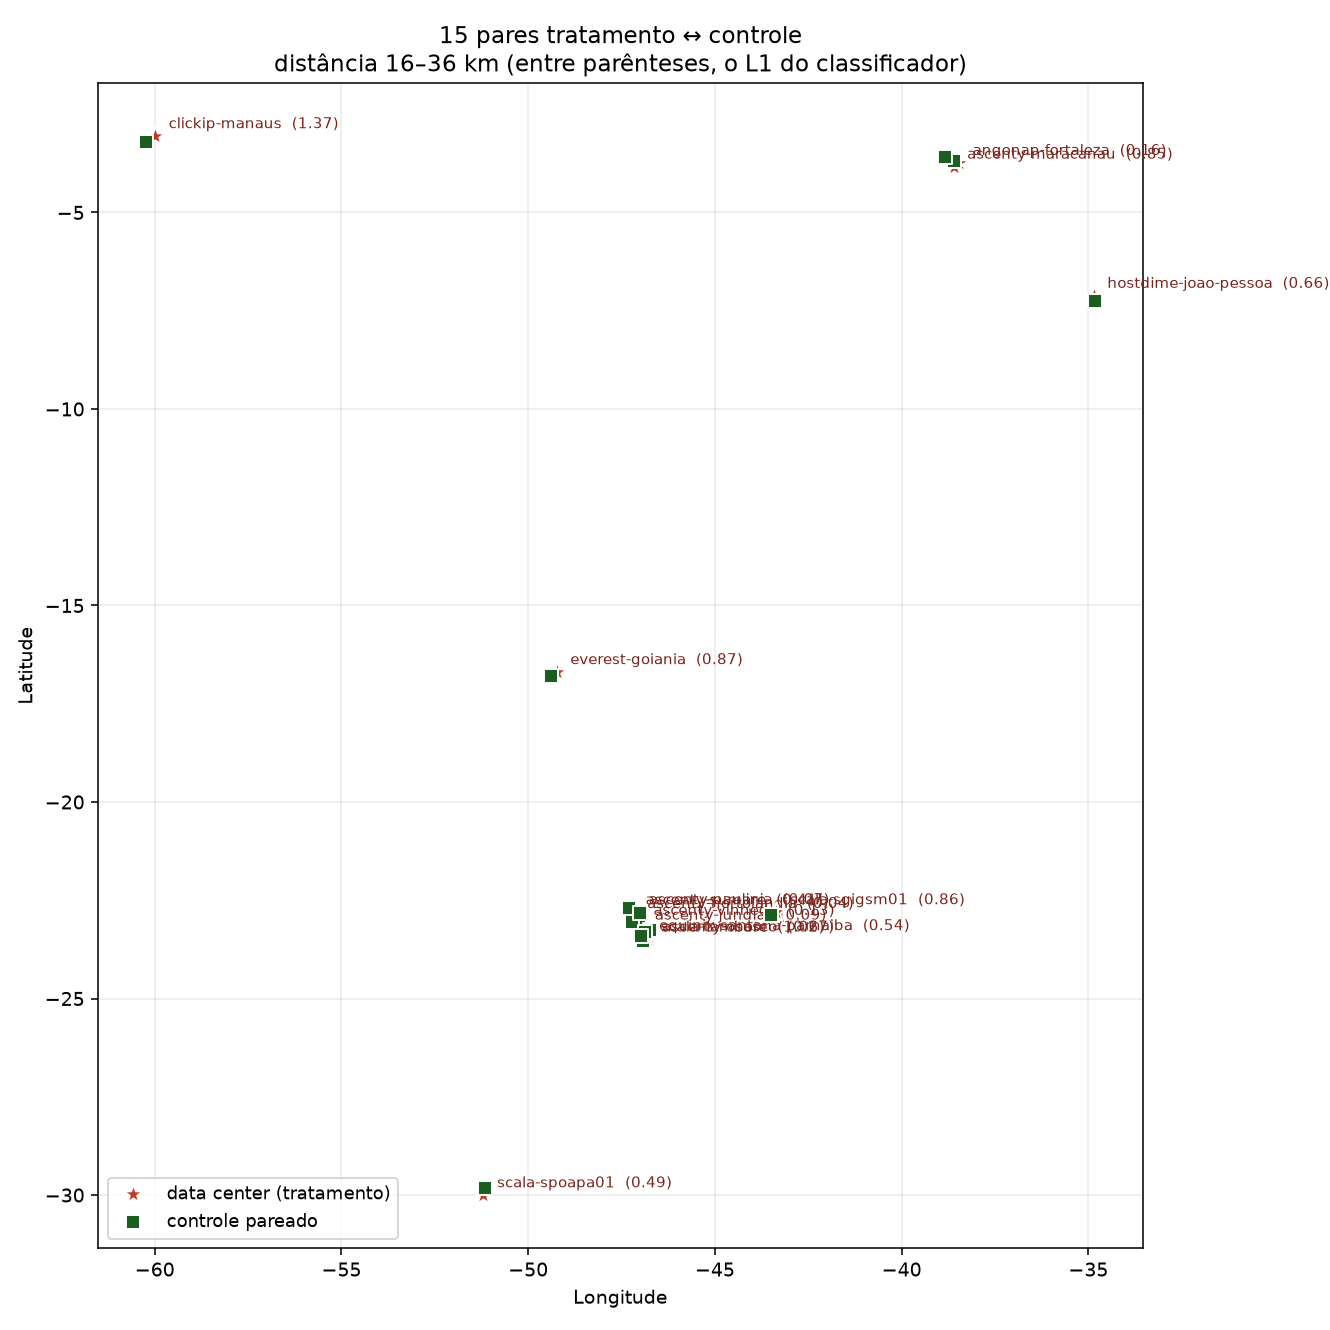

In [9]:
display(Image(filename=str(FIGURAS_DIR / "fig_04_mapa_pares.png")))

**5 de 15 pares ficaram dentro do limiar de qualidade** (`bom` ou `aceitavel`) — abaixo do critério de aceite de SV-29, que pede ≥ 70%. Isso é reportado como achado, não escondido, e nenhum limiar foi afrouxado para melhorar o número.

Os bons são todos Mata Atlântica em São Paulo (Hortolândia 0,036 · Paulínia 0,072 · Jundiaí 0,088). Os piores são Manaus (1,37), Barueri (1,06) e Goiânia (0,87) — **os mesmos que a rodada anterior, com critério diferente, também não conseguiu parear**. Isso aponta para o anel de 15–40 km não ter nada parecido nesses biomas, não para o critério de escolha estar errado.

## 5. A regra do sensor único — o ponto mais importante do desenho

O projeto usa **Landsat 8/9 (30 m)** até 2018 e **Sentinel-2 (10 m)** de 2019 em diante. A troca de instrumento acontece exatamente quando a maioria dos data centers do estudo começou a crescer.

SV-20 (`reports/validacao_sensores.md`) mediu isso na saída do classificador, nos 16 sites × 3 anos de sobreposição. O resultado: em **48 de 48 pares**, o degrau 2018→2019 da classe "solo exposto/obras" (~1.253 ha em média) é **indistinguível do artefato de troca de sensor** (~1.263 ha). A mudança real medida no mesmo sensor, sem trocar de instrumento, é de −9,5 ha — ordens de magnitude menor.

Ou seja: uma janela "antes/depois" que atravessa 2018/2019 mede o satélite, não a obra.

**A regra adotada:** a janela de cada par nunca cruza essa fronteira. Para que isso fosse possível, a ingestão Landsat foi estendida de 2021 para **2024** — Landsat 8/9 cobre esses anos, o repositório simplesmente tinha parado antes. Resultado: **12 campi inteiramente em Landsat** e **3 inteiramente em Sentinel-2** (os de obra em 2022/2023, cuja janela já nasce na era do Sentinel-2).

O gráfico abaixo é a confirmação visual, par a par. Em cima, a série mono-sensor do par. Embaixo, a mesma obra lida dos dois jeitos:

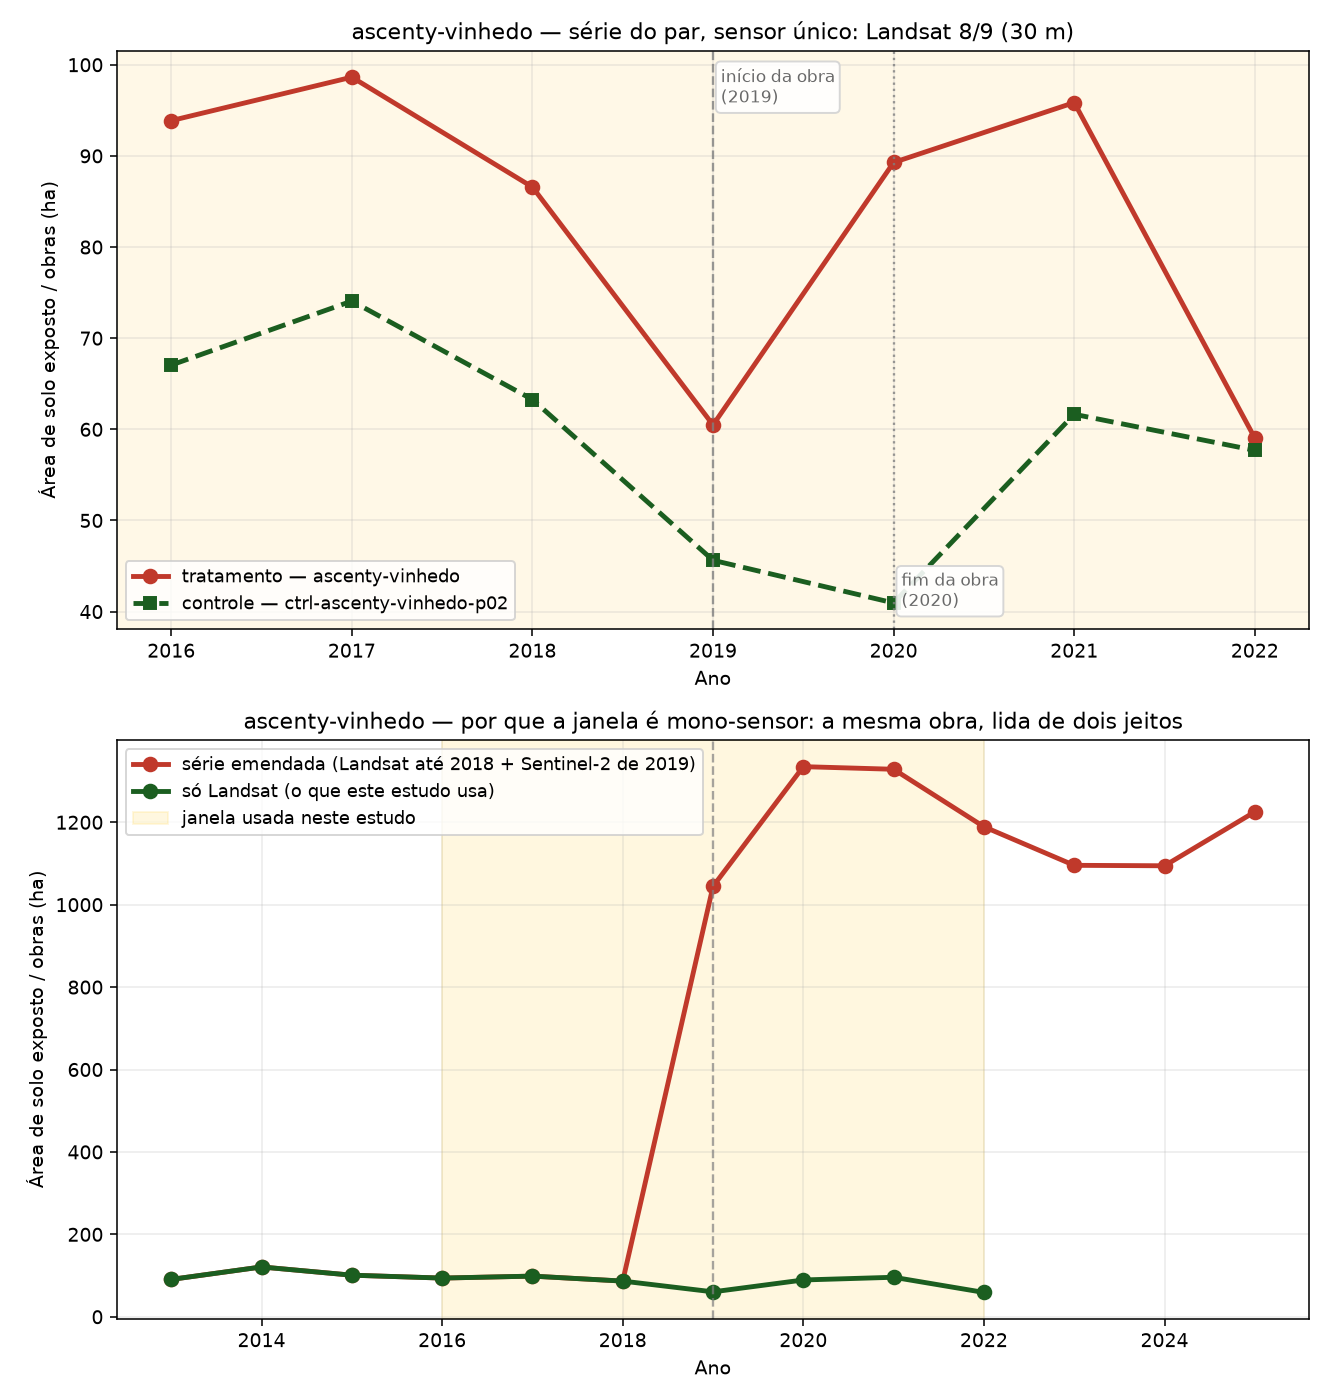

In [10]:
display(Image(filename=str(FIGURAS_DIR / "serie_ascenty-vinhedo.png")))

No painel de baixo, a série emendada salta de ~85 ha (2018, Landsat) para ~1.045 ha (2019, Sentinel-2) — **12 vezes** — enquanto a leitura mono-Landsat fica plana entre 60 e 100 ha. Não houve nenhuma obra de 960 hectares em Vinhedo em 2019: o salto inteiro é troca de instrumento.

> Há uma figura dessas para cada um dos 15 pares, em `modelo-impacto/raw/controles-rf/figuras/serie_*.png`.

## 6. O painel final

Para cada par, área por classe em `obra-3 .. obra+3`, mais o ano de fim de obra quando ele cai fora dessa faixa. **Tratamento e controle sempre nos mesmos anos e no mesmo sensor.**

In [11]:
print(f"{len(painel)} linhas | {painel.site_id.nunique()} pontos | {painel.pareado_com.nunique()} pares "
      f"| anos {painel.ano.min()}–{painel.ano.max()}")
print("fases:", painel.fase.value_counts().to_dict())
print("pares por sensor:", painel.groupby("sensor").pareado_com.nunique().to_dict())

colunas_amostra = ["site_id", "tipo", "ano", "ano_relativo_ao_inicio_obra", "fase", "sensor",
                   "area_ha_solo_exposto_obras", "area_ha_construida_urbana", "area_ha_vegetacao_densa"]
painel[painel.pareado_com == "ascenty-vinhedo"][colunas_amostra]

204 linhas | 30 pontos | 15 pares | anos 2013–2025
fases: {'pre': 86, 'durante': 70, 'pos': 48}
pares por sensor: {'landsat': 12, 's2': 3}


,site_id,tipo,ano,ano_relativo_ao_inicio_obra,fase,sensor,area_ha_solo_exposto_obras,area_ha_construida_urbana,area_ha_vegetacao_densa
96,ctrl-ascenty-vinhedo-p02,controle,2016,-3,pre,landsat,67.05,2355.39,953.64
97,ctrl-ascenty-vinhedo-p02,controle,2017,-2,pre,landsat,74.07,2547.81,842.22
98,ctrl-ascenty-vinhedo-p02,controle,2018,-1,pre,landsat,63.27,2357.64,962.82
99,ctrl-ascenty-vinhedo-p02,controle,2019,0,durante,landsat,45.63,2119.77,1320.03
100,ctrl-ascenty-vinhedo-p02,controle,2020,1,durante,landsat,40.95,2008.17,1454.67
101,ctrl-ascenty-vinhedo-p02,controle,2021,2,pos,landsat,61.65,2545.47,472.77
102,ctrl-ascenty-vinhedo-p02,controle,2022,3,pos,landsat,57.69,2517.21,1120.50
103,ascenty-vinhedo,tratamento,2016,-3,pre,landsat,93.87,2377.53,1745.64
104,ascenty-vinhedo,tratamento,2017,-2,pre,landsat,98.64,2499.21,1619.82
105,ascenty-vinhedo,tratamento,2018,-1,pre,landsat,86.58,2468.43,1497.69


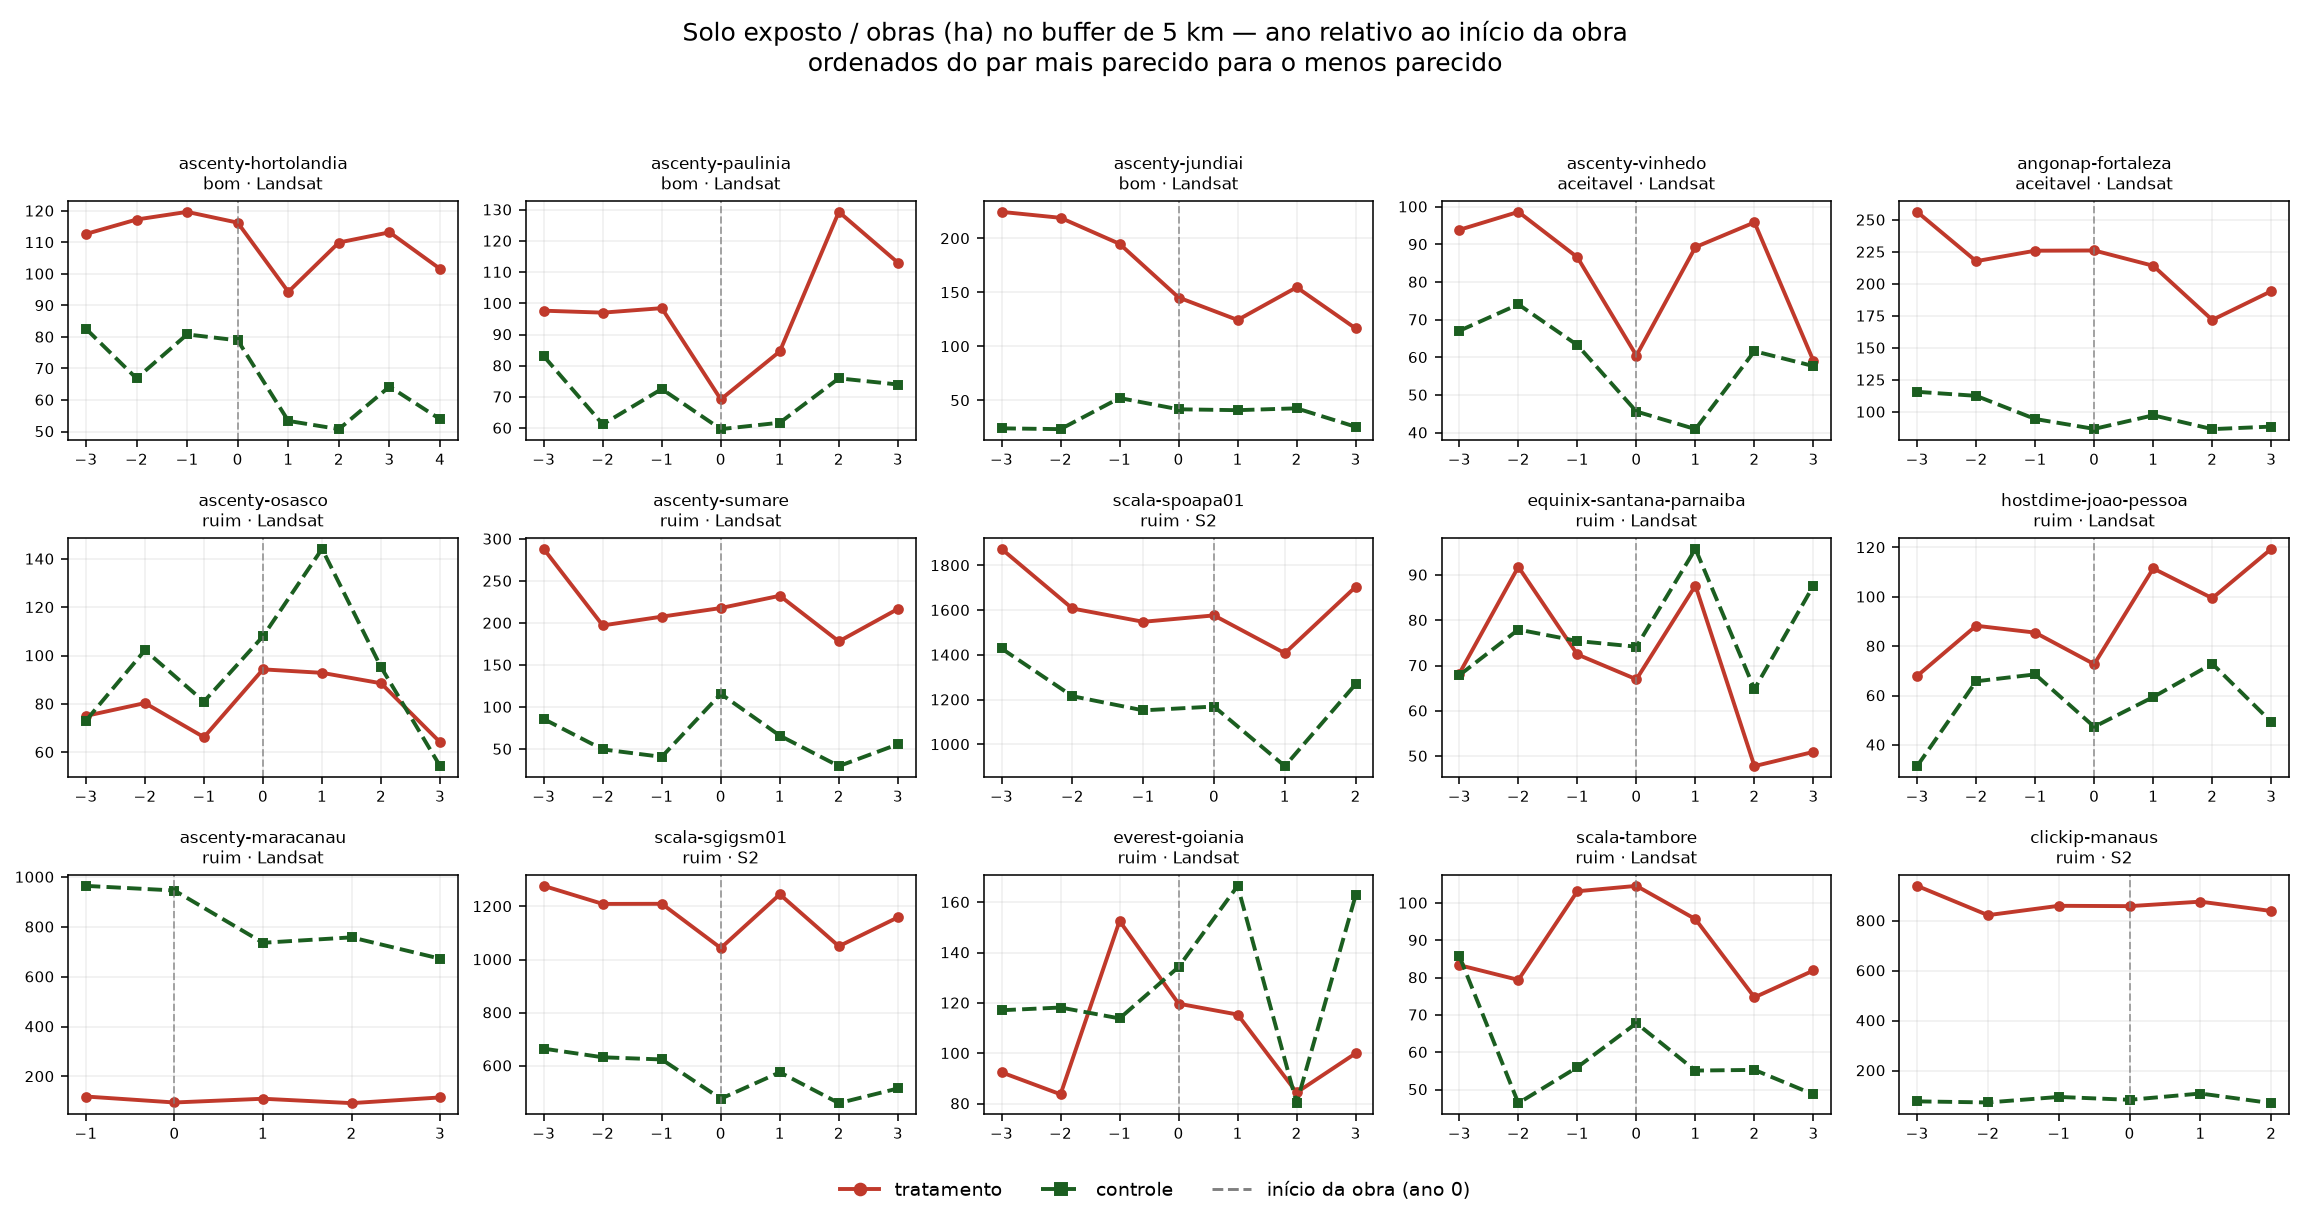

In [12]:
display(Image(filename=str(FIGURAS_DIR / "fig_05_painel_series.png")))

Lendo os pequenos múltiplos: o que interessa ao modelo de impacto **não é a linha vermelha subir**, é ela subir **diferente da verde**. Onde as duas se movem juntas (`equinix-santana-parnaiba`, `everest-goiania`), a variação é regional e não do empreendimento. Onde divergem depois do ano 0, há sinal a investigar.

E é aqui que a qualidade do par pesa: nos 10 pares `ruim`, tratamento e controle partem de níveis tão diferentes que comparar as trajetórias exige cuidado — o desenho pede diferença de diferenças, não comparação de nível.

## 7. O consolidado — a tabela que vai para o modelo

O painel de cobertura do solo é só um dos blocos. O consolidado junta tudo que esta frente
produziu numa tabela só, `processed/consolidado_impacto_painel.csv` — **204 linhas × 51 colunas**,
uma por (ponto, ano).

| bloco | fonte | tratamento | controle |
|---|---|---|---|
| cobertura do solo (5 classes, ha e proporção) | classificador `rf_v1.0-tuned` | sim | sim |
| temperatura de superfície (LST) | MODIS MOD11A2 | sim | sim |
| população, emprego formal, PIB | IBGE (SIDRA) | sim | sim |
| MW construído, whitespace, tier, nº prédios | scraping do Guilherme | sim | **não existe** |
| qualidade do pareamento (L1, distância) | passo 3 | sim | sim |

O último bloco ficar vazio no controle **não é lacuna**: o controle é, por definição, um lugar sem
data center.

### O que foi preciso coletar para o painel ficar simétrico

As tabelas socioeconômicas que já existiam nesta pasta cobriam **só o tratamento** e começavam em
**2016**. Um grupo de controle sem contrafactual nessas variáveis não serve para nada, então:

- **LST** foi coletada para os 30 pontos e a série estendida para 2013 — o corte em 2016 era o
  "10 anos de histórico" do briefing anterior, não limite do MODIS (que cobre desde 2000).
- **População, emprego e PIB** foram coletados para os 27 municípios do painel, 13 deles de
  controle e nunca antes consultados.

Nos dois casos, tratamento e controle passaram pelo **mesmo código, na mesma execução, contra as
mesmas tabelas** — a mesma disciplina que a regra de sensor único aplica à cobertura do solo. Se
as duas pontas de uma comparação vierem de fontes diferentes, a diferença entre elas deixa de ser
interpretável.

In [13]:
consolidado = pd.read_csv(IMPACTO_DIR / "processed" / "consolidado_impacto_painel.csv")
print(f"{len(consolidado)} linhas x {len(consolidado.columns)} colunas")
print()
print("cobertura por bloco (não-nulos):")
for col in ["area_ha_solo_exposto_obras", "lst_media_celsius", "populacao",
            "emprego_formal_total", "pib_mil_reais", "mw_construido_total"]:
    c = consolidado.groupby("tipo")[col].apply(lambda s: f"{s.notna().sum()}/{len(s)}").to_dict()
    print(f"  {col:32} tratamento={c['tratamento']:>8}  controle={c['controle']:>8}")

204 linhas x 51 colunas

cobertura por bloco (não-nulos):
  area_ha_solo_exposto_obras       tratamento= 102/102  controle= 102/102
  lst_media_celsius                tratamento= 102/102  controle= 102/102
  populacao                        tratamento=  85/102  controle=  85/102
  emprego_formal_total             tratamento=  99/102  controle=  99/102
  pib_mil_reais                    tratamento=  94/102  controle=  94/102
  mw_construido_total              tratamento=  70/102  controle=   0/102


As lacunas de população, emprego e PIB são **idênticas nos dois lados** e vêm da fonte, não do
método: a estimativa do IBGE não cobre 2013–2015 nem 2023, o CEMPRE vai até 2024 e o PIB municipal
até 2023.

`mw_construido_total` é outra história — ver a seção seguinte.

In [14]:
colunas = ["site_id", "tipo", "ano", "fase", "area_ha_solo_exposto_obras",
           "lst_media_celsius", "populacao", "emprego_formal_total", "pib_mil_reais",
           "mw_construido_total"]
consolidado[consolidado.pareado_com == "ascenty-vinhedo"][colunas]

,site_id,tipo,ano,fase,area_ha_solo_exposto_obras,lst_media_celsius,populacao,emprego_formal_total,pib_mil_reais,mw_construido_total
96,ctrl-ascenty-vinhedo-p02,controle,2016,pre,67.05,29.9206,1173370.0,400781.0,57778152.0,NaN
97,ctrl-ascenty-vinhedo-p02,controle,2017,pre,74.07,29.3745,1182429.0,401356.0,58469540.0,NaN
98,ctrl-ascenty-vinhedo-p02,controle,2018,pre,63.27,29.4419,1194094.0,401348.0,61388555.0,NaN
99,ctrl-ascenty-vinhedo-p02,controle,2019,durante,45.63,30.2983,1204073.0,400552.0,65837258.0,NaN
100,ctrl-ascenty-vinhedo-p02,controle,2020,durante,40.95,30.8430,1213792.0,385683.0,65158382.0,NaN
101,ctrl-ascenty-vinhedo-p02,controle,2021,pos,61.65,30.7956,1223237.0,404030.0,72946910.0,NaN
102,ctrl-ascenty-vinhedo-p02,controle,2022,pos,57.69,28.9387,1139047.0,420374.0,80646591.0,NaN
103,ascenty-vinhedo,tratamento,2016,pre,93.87,28.2856,73855.0,35123.0,8085038.0,61.0
104,ascenty-vinhedo,tratamento,2017,pre,98.64,28.2084,75129.0,34638.0,8704161.0,61.0
105,ascenty-vinhedo,tratamento,2018,pre,86.58,28.3050,77308.0,35386.0,9275194.0,61.0


### Duas armadilhas que a tabela contém

**1. `mw_construido_total` falta exatamente fora do Sudeste.** A medida mais natural de
"intensidade do tratamento" existe para 10 dos 15 campi — e a lacuna não é aleatória:

In [15]:
por_regiao = (
    consolidado[consolidado.tipo == "tratamento"]
    .groupby("pareado_com")
    .agg(regiao=("regiao", "first"), bioma=("bioma", "first"), mw=("mw_construido_total", "first"))
    .assign(tem_mw=lambda d: d.mw.notna())
    .groupby("regiao").tem_mw.agg(com_mw="sum", campi="count")
)
por_regiao

,com_mw,campi
regiao,,
Centro-Oeste,0,1
Nordeste,0,3
Norte,0,1
Sudeste,9,9
Sul,1,1


9 de 9 no Sudeste, 1 de 1 no Sul, **0 de 5** no Nordeste, Norte e Centro-Oeste. Usar MW como
regressor de intensidade derruba a amostra para 10 campi e elimina *todos* os biomas fora da Mata
Atlântica — inclusive vários dos pares de pior qualidade. **O modelo pareceria melhor por um motivo
que nada tem a ver com data center.**

**2. Os municípios pareados têm portes muito diferentes.** O pareamento foi por cobertura do solo
num buffer de 5 km — que é o que o classificador mede. Porte de município não entrou em critério
nenhum, e o resultado aparece aqui:

In [16]:
pop = (
    consolidado[consolidado.populacao.notna()]
    .groupby(["pareado_com", "tipo"]).populacao.max().unstack()
)
pop["razao_controle_tratamento"] = (pop.controle / pop.tratamento).round(2)
fora = ((pop.razao_controle_tratamento < 0.5) | (pop.razao_controle_tratamento > 2.0)).sum()
print(f"{fora} de {len(pop)} pares com razão de população fora da faixa 0,5-2,0")
pop.sort_values("razao_controle_tratamento")

11 de 15 pares com razão de população fora da faixa 0,5-2,0


tipo,controle,tratamento,razao_controle_tratamento
pareado_com,,,
hostdime-joao-pessoa,25010.0,817511.0,0.03
clickip-manaus,68862.0,2303732.0,0.03
scala-tambore,19453.0,330339.0,0.06
scala-spoapa01,142508.0,1492530.0,0.10
angonap-fortaleza,365212.0,2686612.0,0.14
ascenty-jundiai,86407.0,443221.0,0.19
ascenty-osasco,244131.0,728615.0,0.34
equinix-santana-parnaiba,92689.0,154105.0,0.60
ascenty-sumare,256223.0,286211.0,0.90


A razão vai de **0,03** (João Pessoa, 818 mil, pareada com Conde, 25 mil) a **15,0** (Vinhedo,
82 mil, pareada com Campinas, 1,2 milhão).

**Consequência prática para o modelo:** comparar o **nível** de população, emprego ou PIB entre
tratamento e controle não significa nada. Só a **variação relativa dentro de cada município** ao
longo do tempo é interpretável — e mesmo essa, com a ressalva de sempre: são variáveis municipais,
e um data center de dezenas de hectares é fração ínfima de um município inteiro.

### O que ficou de fora, de propósito

`consolidado_renda.csv`, `consolidado_desemprego.csv` e `consolidado_escolaridade.csv` existem em
`processed/`, mas só do lado do tratamento e com cobertura irregular (renda só em 2022; desemprego
só em 5 dos 18 municípios, porque o IBGE só publica a taxa municipal para capitais; escolaridade
com cortes etários diferentes entre 2010 e 2022). Uma variável que existe de um lado só da
comparação não é utilizável num desenho com grupo de controle — entrariam quebrando a simetria que
o resto do painel foi feito para garantir. Seguem disponíveis nas tabelas originais, como contexto.

> Dicionário de todas as 51 colunas: `processed/consolidado_impacto_dicionario.csv`, e aba
> `dicionario` de `consolidado_impacto_modelo.xlsx`.

## 8. A obra aparece nos dados? — e por que quase dissemos que não

Com o painel montado, a pergunta seguinte é direta: **dá para ver a construção do data center?**

A primeira resposta foi não — e ela estava certa para a estatística que estávamos usando.

### Somar área por classe não detecta nada

Testamos em 6 raios (0,5 a 5 km) e nas 3 classes relevantes. Se a obra expõe solo, o tratamento
teria que subir mais que o controle na **maioria** dos pares:

In [17]:
sens = pd.read_csv(CONTROLES_DIR / "sensibilidade_buffer_resumo.csv")
sens[sens.classe == "solo_exposto_obras"][
    ["raio_km", "area_buffer_ha", "n_did_positivo", "n_pares", "frac_positivo", "p_binomial"]
].sort_values("raio_km")

,raio_km,area_buffer_ha,n_did_positivo,n_pares,frac_positivo,p_binomial
0,0.5,78.5,7,15,0.467,1.0000
3,1.0,314.2,8,15,0.533,1.0000
6,1.5,706.9,6,15,0.400,0.6072
9,2.0,1256.6,6,15,0.400,0.6072
12,3.0,2827.4,6,15,0.400,0.6072
15,5.0,7854.0,3,15,0.200,0.0352


Fica em torno de 0,5 na faixa inteira — cara ou coroa. O teste de forma (em que fase a série
ajustada pelo controle atinge o pico) também não achou nada: o pico de solo exposto cai na fase de
obra 4 vezes em 15, contra 5,1 esperadas pelo acaso.

**A hipótese de que o buffer era grande demais foi testada e refutada.** A 0,5 km o data center
ocuparia 2 a 25% da área medida, e mesmo assim nada aparece.

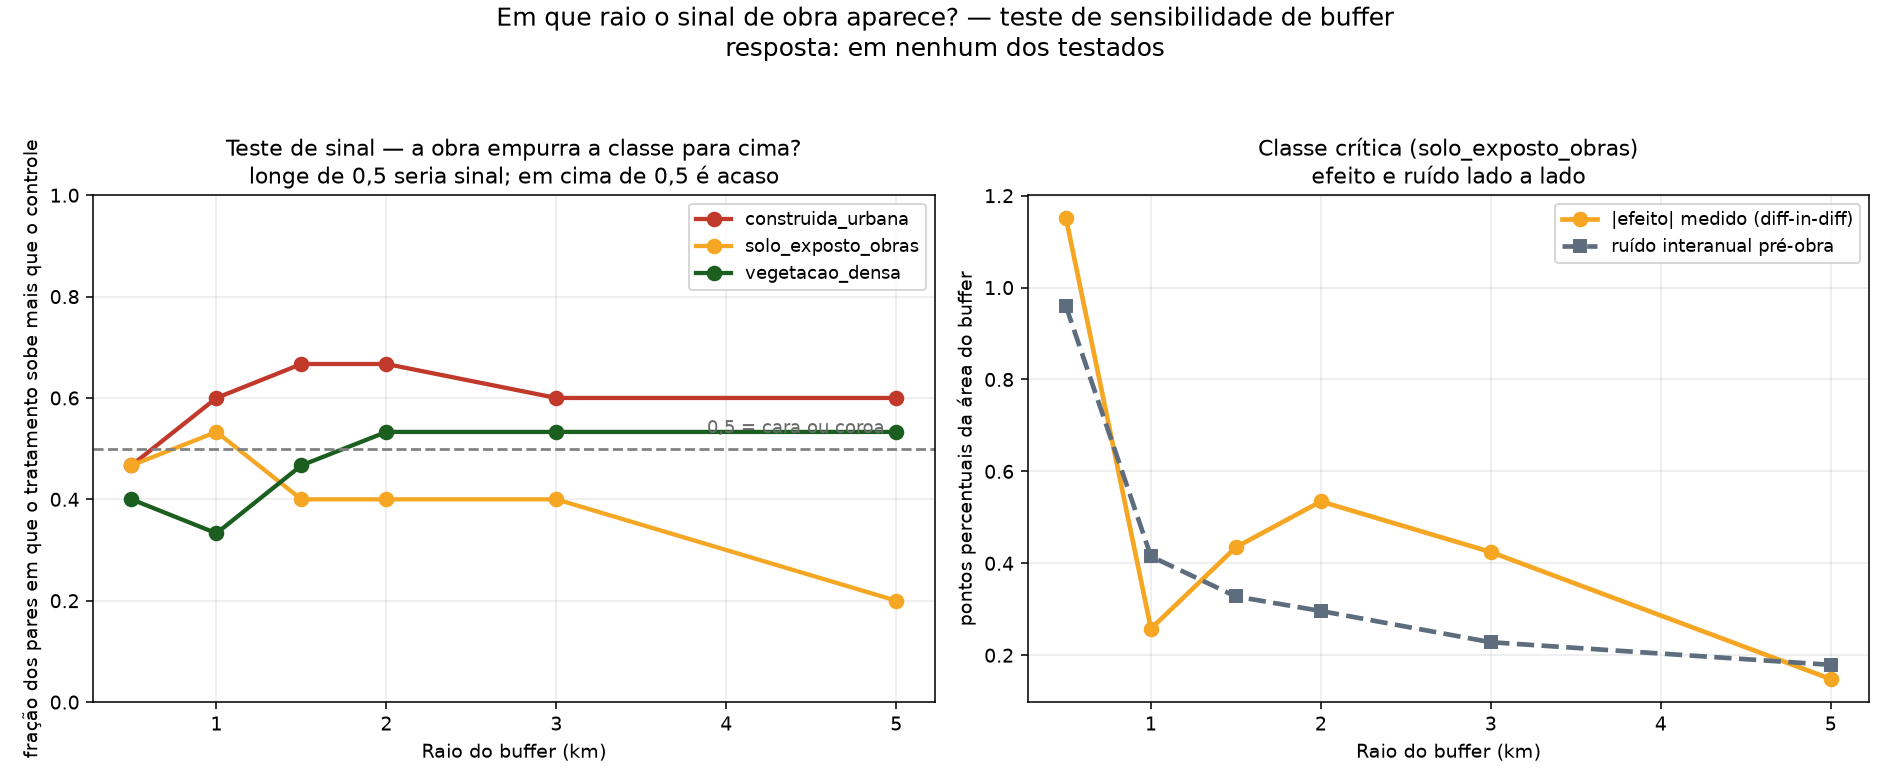

In [18]:
display(Image(filename=str(FIGURAS_DIR / "fig_06_sensibilidade_buffer.png")))

### A causa: pedimos ao instrumento mais fraco que medisse o sinal menor

`solo_exposto_obras` é, de longe, a pior classe do classificador:

| classe | F1 |
|---|---:|
| Água | 0,920 |
| Vegetação densa | 0,879 |
| Área construída/urbana | 0,764 |
| Vegetação rala | 0,736 |
| **Solo exposto / em obras** | **0,579** |

Precisão 0,587 e recall 0,572: **41% do que ele chama de solo exposto não é, e ele perde 43% do que
é.** O repositório já sabia por quê (ADR-004): o MapBiomas **não tem classe "canteiro de obras"**,
então os rótulos dessa classe são um proxy de solo nu natural.

Numa soma de área, cada falso positivo pesa igual a um pixel verdadeiro. Num disco de milhares de
pixels, 41% de falsos positivos afogam uma obra de algumas dezenas.

### Trocar a estatística: trajetória em vez de área

Em vez de perguntar *"quanta classe 3 há no disco"*, perguntar *"quantos pixels fizeram uma
trajetória de construção"*. Para um pixel contar, ele precisa:

1. **não** ser construída nos 2 primeiros anos da janela,
2. **ser** construída nos 2 últimos — e permanecer,
3. (na variante estrita) ter passado por solo exposto num ano intermediário.

Um falso positivo isolado não satisfaz uma sequência ordenada e persistente. Três anos coerentes
satisfazem. O controle dá a hipótese nula: quantos pixels fazem essa trajetória, no mesmo período e
na mesma região, sem data center nenhum.

In [19]:
traj = pd.read_csv(CONTROLES_DIR / "trajetoria_pixel_resumo.csv")
traj[["assinatura", "raio_km", "n_positivo", "n_pares", "frac_positivo",
      "p_unilateral", "excesso_mediano_pp"]].sort_values(["assinatura", "raio_km"])

,assinatura,raio_km,n_positivo,n_pares,frac_positivo,p_unilateral,excesso_mediano_pp
2,vegetacao_para_construida,0.5,11,15,0.733,0.0592,0.6638
5,vegetacao_para_construida,1.0,11,15,0.733,0.0592,0.5857
8,vegetacao_para_construida,2.0,9,15,0.600,0.3036,0.2013
11,vegetacao_para_construida,5.0,8,15,0.533,0.5000,0.0445
0,virou_construida,0.5,13,15,0.867,0.0037,1.9331
3,virou_construida,1.0,13,15,0.867,0.0037,0.8879
6,virou_construida,2.0,9,15,0.600,0.3036,0.6200
9,virou_construida,5.0,11,15,0.733,0.0592,0.2763
1,virou_construida_via_solo,0.5,9,15,0.600,0.3036,0.2300
4,virou_construida_via_solo,1.0,13,15,0.867,0.0037,0.3827


**13 de 15 pares, p = 0,0037** — e sobrevive à correção de Bonferroni para as 12 combinações
testadas (p ajustado = 0,044). É a primeira medida desta frente que passa num teste estatístico.

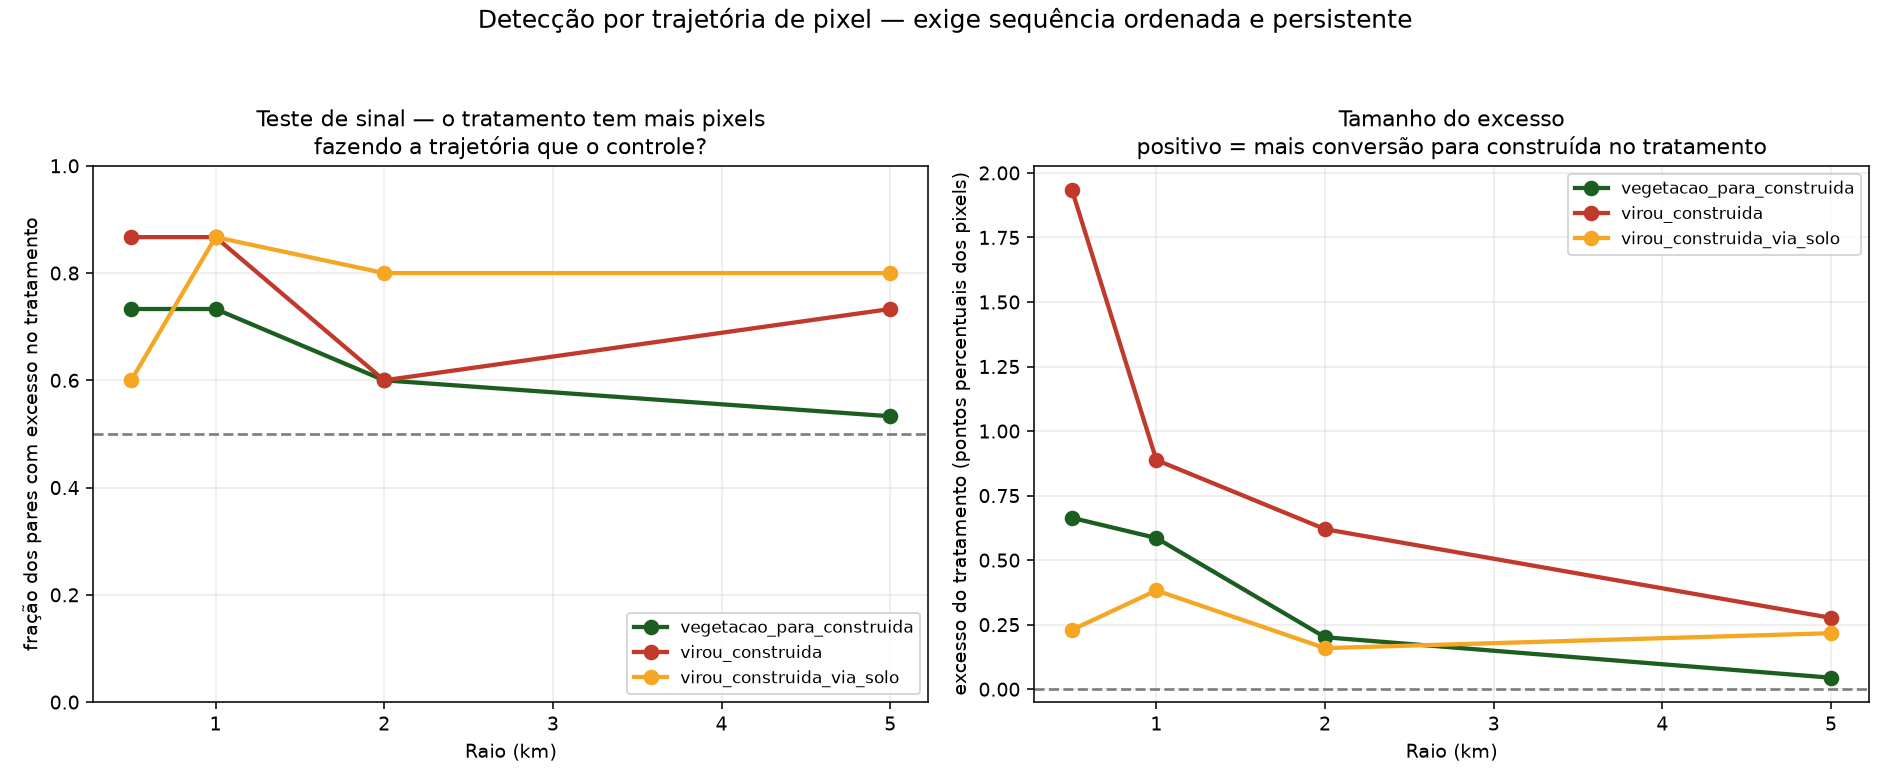

In [20]:
display(Image(filename=str(FIGURAS_DIR / "fig_07_trajetoria_pixel.png")))

### As duas checagens que tentaram derrubar o achado

Um resultado positivo com N=15 merece mais desconfiança que um negativo.

**1. O excesso é do terreno ou da região?** Data centers são construídos onde já há
desenvolvimento. Se o excesso fosse tendência regional, cresceria junto com a área do disco.

In [21]:
loc = pd.read_csv(CONTROLES_DIR / "trajetoria_pixel_localizacao.csv")
loc[loc.assinatura == "virou_construida"][
    ["raio_km", "area_disco_ha", "excesso_mediano_pp", "excesso_mediano_ha",
     "crescimento_vs_menor_raio", "crescimento_do_disco"]
]

,raio_km,area_disco_ha,excesso_mediano_pp,excesso_mediano_ha,crescimento_vs_menor_raio,crescimento_do_disco
0,0.5,78.5,1.9331,1.53,1.00,1.0
1,1.0,314.2,0.8879,2.71,1.77,4.0
2,2.0,1256.6,0.6200,7.83,5.10,16.0
3,5.0,7854.0,0.2763,17.75,11.57,100.0


O disco cresce **100×** de 0,5 km a 5 km; o excesso cresce **11,6×**. A densidade do excesso cai 7×
com o raio — assinatura de mudança concentrada no terreno, não de uma região urbanizando inteira.

**2. As tendências eram paralelas antes da obra?** É a hipótese identificadora de
diferença-em-diferenças. Se o tratamento já crescia mais rápido que o controle **antes** de o data
center existir, o excesso medido depois é viés de localização, não efeito.

In [22]:
par = pd.read_csv(CONTROLES_DIR / "trajetoria_pixel_tendencias_paralelas.csv")
n_pos = int((par.diferenca_pp_ano > 0).sum())
print(f"tratamento com inclinação pré-obra maior que o controle: {n_pos} de {len(par)}")
print(f"diferença mediana de inclinação: {par.diferenca_pp_ano.median():+.4f} pp/ano")
par.sort_values("diferenca_pp_ano", ascending=False)

tratamento com inclinação pré-obra maior que o controle: 6 de 14
diferença mediana de inclinação: -0.1604 pp/ano


,pareado_com,inclinacao_tratamento_pp_ano,inclinacao_controle_pp_ano,diferenca_pp_ano
1,ascenty-hortolandia,2.1937,0.2663,1.9273
7,clickip-manaus,1.0720,0.1051,0.9669
13,scala-tambore,-0.1453,-0.8993,0.7541
5,ascenty-sumare,0.4503,-0.1076,0.5578
6,ascenty-vinhedo,0.4495,0.0221,0.4274
3,ascenty-osasco,-1.1455,-1.1838,0.0383
10,hostdime-joao-pessoa,1.4052,1.4938,-0.0886
4,ascenty-paulinia,0.0538,0.2860,-0.2322
11,scala-sgigsm01,0.4634,0.7124,-0.2490
2,ascenty-jundiai,-0.2913,-0.0306,-0.2607


**6 de 14** (p = 0,79), com diferença mediana ligeiramente **negativa**. Antes da obra os
tratamentos não cresciam mais rápido que seus controles — se algo, um pouco menos. A hipótese
identificadora se sustenta.

### O que isso permite e o que não permite dizer

**Permite:** a construção de um data center está associada a um excesso de conversão para área
construída no entorno imediato, da ordem de **1,5 ha** num raio de 500 m, concentrado no terreno e
não explicado por tendência regional prévia.

**Não permite:** afirmar magnitude com precisão, nem generalizar para data centers fora desta
amostra. N=15, 2 dos 15 pares vão na direção contrária, e 10 dos 15 controles são de qualidade
`ruim`. É um resultado sugestivo com validações que se sustentam — não uma estimativa de efeito.

## 9. É o prédio ou é o entorno? — o footprint real

O passo anterior achou excesso de conversão para área construída num raio de 500 m. Mas um disco de
500 m tem 78 ha, e o data center é uma fração disso. Duas leituras muito diferentes cabem no mesmo
número:

- **"o data center ocupa N hectares"** — trivial; é a definição do empreendimento, não impacto;
- **"o data center puxa urbanização em volta"** — a afirmação que interessa ao modelo.

Para separar as duas, puxamos o **polígono real** de cada data center no OpenStreetMap.

In [23]:
footprints = pd.read_csv(CONTROLES_DIR / "footprints_osm.csv")
print(footprints.metodo_footprint.value_counts().to_string())
footprints[footprints.metodo_footprint.str.startswith("osm_", na=False)][
    ["site_id", "metodo_footprint", "osm_id", "area_footprint_ha", "dist_ponto_ao_footprint_km"]
].sort_values("dist_ponto_ao_footprint_km")

metodo_footprint
osm_data_center_explicito      7
osm_landuse_industrial         6
sem_footprint                  1
osm_edificacao_mais_proxima    1


,site_id,metodo_footprint,osm_id,area_footprint_ha,dist_ponto_ao_footprint_km
4,ascenty-osasco,osm_data_center_explicito,way/673758677,0.8102,0.0128
3,ascenty-maracanau,osm_data_center_explicito,way/1167125352,0.8215,0.0143
8,clickip-manaus,osm_data_center_explicito,way/1331645888,0.1459,0.0167
2,ascenty-jundiai,osm_landuse_industrial,way/697891659,1.0603,0.0299
5,ascenty-paulinia,osm_landuse_industrial,way/713812352,1.5176,0.0614
0,angonap-fortaleza,osm_data_center_explicito,way/808900331,0.9046,0.1096
1,ascenty-hortolandia,osm_landuse_industrial,way/713804589,13.1197,0.1327
13,scala-spoapa01,osm_landuse_industrial,way/356396366,0.1073,0.1725
11,hostdime-joao-pessoa,osm_edificacao_mais_proxima,way/1500626299,0.1909,0.1989
14,scala-tambore,osm_data_center_explicito,way/1472333082,1.9380,0.2569


**14 de 15** campi com footprint, **7 deles com `building=data_center` explícito**. E um brinde
metodológico: três desses casaram a **13–30 m** do ponto que o repositório já tinha validado por
cinco outras camadas — confirmação independente das coordenadas, por uma fonte que não participou
daquela validação.

### O que parecia falha do classificador

Dentro do footprint, só **4,8%** dos pixels (mediana) viraram construída. Lido isolado, isso
derrubaria tudo: se o classificador não vê o prédio aparecer, o excesso do passo 8 vem de outra
coisa. Mas há uma segunda explicação, e ela é a certa:

In [24]:
fp_zonas = pd.read_csv(CONTROLES_DIR / "footprint_vs_anel.csv")
dentro = fp_zonas[(fp_zonas.zona == "footprint") & (fp_zonas.n_pixels_footprint > 0)]
dentro[["pareado_com", "area_zona_ha", "n_pixels_footprint", "pct_ja_construida",
        "pct_virou_construida_fp", "pct_construida_no_fim"]].sort_values("pct_ja_construida")

,pareado_com,area_zona_ha,n_pixels_footprint,pct_ja_construida,pct_virou_construida_fp,pct_construida_no_fim
56,clickip-manaus,0.1459,20.0,0.00,75.00,75.00
63,equinix-santana-parnaiba,9.8868,138.0,0.00,0.72,1.45
0,angonap-fortaleza,0.9046,18.0,22.22,22.22,66.67
84,scala-spoapa01,0.1073,19.0,31.58,15.79,52.63
7,ascenty-hortolandia,13.1197,179.0,31.84,16.20,65.92
49,ascenty-vinhedo,1.6340,31.0,35.48,22.58,54.84
35,ascenty-paulinia,1.5176,30.0,50.00,16.67,76.67
70,hostdime-joao-pessoa,0.1909,6.0,50.00,0.00,33.33
77,scala-sgigsm01,3.6565,421.0,71.26,1.90,21.38
14,ascenty-jundiai,1.0603,21.0,85.71,4.76,90.48


**Metade do footprint (mediana 50%) já era classificada como construída antes da obra** — e em
quatro campi, 85 a 90%. Não havia o que ver aparecer.

Isso fecha com três evidências independentes:

- as tags **`Retrofitted`** na planilha do Guilherme;
- os footprints que vieram como **`landuse=industrial`**, ou seja, lotes em parques industriais;
- o contra-exemplo perfeito: **`clickip-manaus`** é o único campus com **0%** de terreno previamente
  construído — e ali o classificador viu **75%** dos pixels do footprint converterem.

**Estes data centers foram erguidos dentro de parques industriais que já existiam.**

### A consequência: o excesso é o entorno, não o prédio

In [25]:
zonas = pd.read_csv(CONTROLES_DIR / "footprint_vs_anel_resumo.csv")
zonas[zonas.assinatura == "virou_construida"][
    ["zona", "n_positivo", "n_pares", "frac_positivo", "p_unilateral", "excesso_mediano_pp"]
]

,zona,n_positivo,n_pares,frac_positivo,p_unilateral,excesso_mediano_pp
0,0-0.5km,12,14,0.857,0.0065,2.0589
3,0.5-1km,12,14,0.857,0.0065,1.1548
6,1-2km,8,14,0.571,0.3953,0.5114


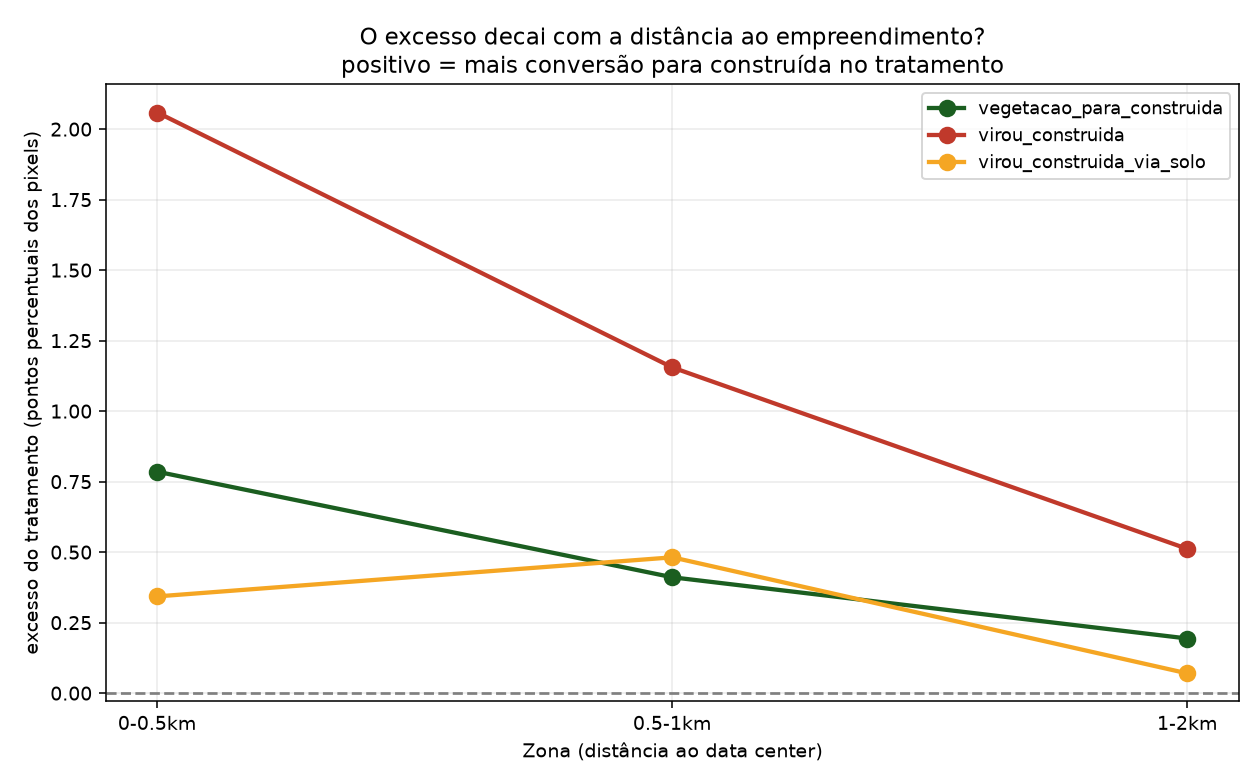

In [26]:
display(Image(filename=str(FIGURAS_DIR / "fig_08_footprint_vs_anel.png")))

Decaimento monotônico, e o sinal morre entre 1 e 2 km. Como o footprint em si estava em boa parte
já construído, o excesso medido **não é o prédio** — é conversão no entorno dele. É a afirmação
mais forte das duas, e a que exige mais cautela.

### Onde havia terreno para converter, o efeito é mais nítido

Se o sítio já estava saturado de área construída, sobra pouco terreno convertível — e o excesso
deveria encolher por um motivo **mecânico**, não por o data center ter menos efeito. Testável:

In [27]:
gb = pd.read_csv(CONTROLES_DIR / "greenfield_brownfield.csv")
z0 = gb[gb.zona == "0-0.5km"].sort_values("pct_ja_construida")
z0[["pareado_com", "tipo_sitio", "pct_ja_construida", "excesso_pp"]]

,pareado_com,tipo_sitio,pct_ja_construida,excesso_pp
0,clickip-manaus,greenfield,0.00,5.3389
1,equinix-santana-parnaiba,greenfield,0.00,1.1476
2,angonap-fortaleza,greenfield,22.22,1.9331
3,scala-spoapa01,greenfield,31.58,0.2876
4,ascenty-hortolandia,greenfield,31.84,3.1011
5,ascenty-vinhedo,greenfield,35.48,2.8649
6,ascenty-paulinia,brownfield,50.00,6.3634
7,hostdime-joao-pessoa,brownfield,50.00,0.7746
8,scala-sgigsm01,brownfield,71.26,3.5171
9,ascenty-jundiai,brownfield,85.71,-5.3740


**Greenfield: 6 de 6 pares positivos** (p = 0,016), excesso mediano +2,40 pp.
**Brownfield: 5 de 7** (p = 0,227), mediana +0,77 pp.

E isso explica os dois pares que iam na direção contrária em todo o estudo: `ascenty-jundiai`
(−5,37 pp) e `ascenty-sumare` (−3,08 pp) são justamente os mais saturados, com **86% e 88%** do
footprint já construído antes da obra. Não havia para onde converter.

**Sobre o corte de 50%:** ele foi escolhido *depois* de ver os dados — é um grau de liberdade do
analista e ignorá-lo seria enganoso. Por isso a varredura de limiares:

In [28]:
rob = pd.read_csv(CONTROLES_DIR / "greenfield_brownfield_robustez.csv")
rob[(rob.zona == "0-0.5km")].pivot(index="limiar_pct", columns="tipo_sitio",
                                   values=["n_positivo", "n", "excesso_mediano_pp", "p_unilateral"])

n_positivo                     n            excesso_mediano_pp            p_unilateral           
tipo_sitio brownfield greenfield brownfield greenfield         brownfield greenfield   brownfield greenfield
limiar_pct                                                                                                  
20                9.0        2.0       11.0        2.0             1.9331     3.2432       0.0327     0.2500
30                8.0        3.0       10.0        3.0             1.4796     1.9331       0.0547     0.1250
40                5.0        6.0        7.0        6.0             0.7746     2.3990       0.2266     0.0156
50                5.0        6.0        7.0        6.0             0.7746     2.3990       0.2266     0.0156
60                3.0        8.0        5.0        8.0             0.3311     2.3990       0.5000     0.0039
70                3.0        8.0        5.0        8.0             0.3311     2.3990       0.5000     0.0039
80                2.0        9.0        4.0        9.0            -1.3769     2.8649       0.6875     0.0020

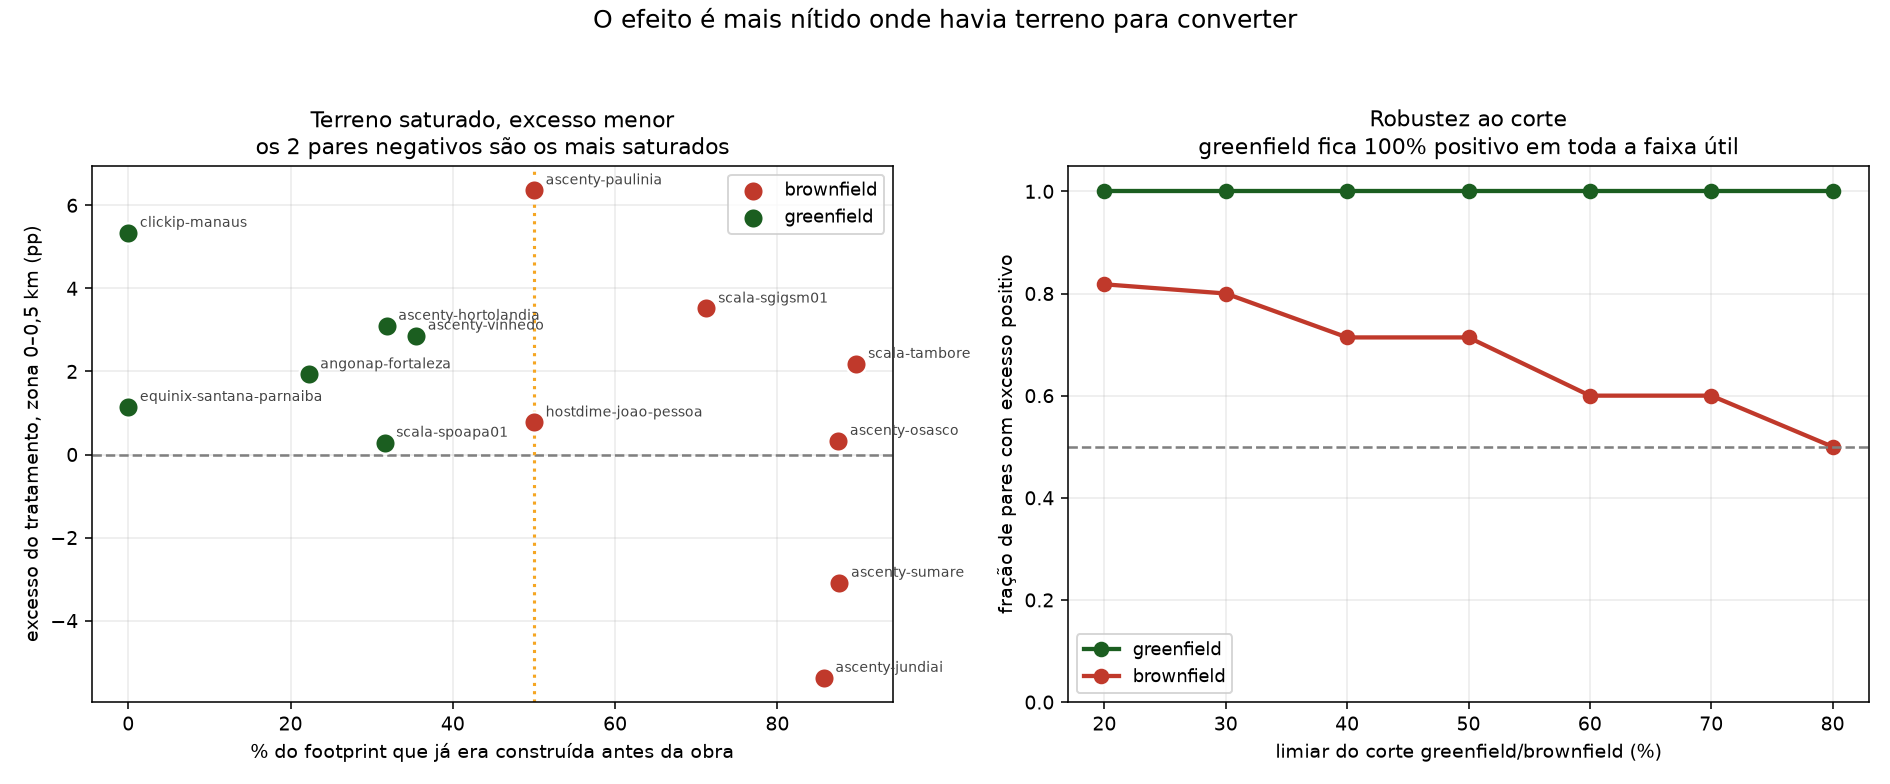

In [29]:
display(Image(filename=str(FIGURAS_DIR / "fig_09_greenfield_brownfield.png")))

Greenfield fica **100% positivo em todos os cortes de 40% a 80%**. O padrão sobrevive à varredura.

O teste contínuo, que não depende de corte nenhum, dá Spearman **−0,31** (n=13): quanto mais
construído o terreno já era, menor o excesso. Direção consistente, magnitude fraca — com n=13 isso
não é significativo isoladamente. **A leitura defensável é a do padrão, não a do coeficiente:** os
casos com terreno disponível convertem, os saturados não, e os dois negativos do estudo inteiro são
os dois mais saturados.

## 10. Limitações honestas

**Os limiares de qualidade não estão na escala certa.** Os cortes 0,10/0,20 vêm de SV-29, onde foram calibrados sobre o L1 do **MapBiomas**. Aqui são aplicados ao L1 do **classificador**, que para o mesmo par corre mais baixo — é o que a figura da seção 3 mostra. Pelo mesmo limiar de 0,20, passam 5 pares medindo pelo classificador contra 2 medindo pelo MapBiomas, **nos mesmos controles**. Os limiares foram mantidos assim mesmo (mudar a régua no meio do estudo é pior), mas comparar o "5 de 15" desta rodada com o "4 de 15" da anterior **não é justo**. Para comparar as duas, use a coluna `l1_mapbiomas` desta contra `l1_cobertura` daquela.

**10 de 15 pares são `ruim`.** Abaixo do critério de aceite de SV-29. Reportado, não mascarado.

**Dois campi não têm nenhum ano pós-obra.** `ascenty-hortolandia` (obra 2018–2022) e `ascenty-osasco` (2020–2023): a construção durou mais que os 3 anos posteriores ao início, então a janela acaba antes de existir um ano pós-construção. Para ler efeito depois da obra, esses dois precisariam de janela ancorada no **fim**, não no início.

**Três janelas são mais curtas que 7 anos.** `ascenty-maracanau` tem 5 (precisaria de 2011–2012, na faixa temporal desabilitada porque a harmonização Landsat 5→8 nunca foi validada); `clickip-manaus` e `scala-spoapa01` têm 6 (obra de 2023, o terceiro ano depois ainda não aconteceu).

**O pré-filtro do MapBiomas pode, em princípio, descartar o melhor candidato** antes que o classificador o veja. Medido (Spearman 0,93; mesmo vencedor em 12 de 15), não eliminado.

**A adjacência de município usa "mesma microrregião do IBGE" como proxy de "município vizinho"**, não a malha poligonal oficial de fronteiras.

**`mw_construido_total` falta exatamente fora do Sudeste** (0 de 5 campi em Nordeste, Norte e Centro-Oeste), então usá-la como intensidade de tratamento reduz a amostra a 10 campi e a um bioma só.

**Os municípios pareados têm portes muito diferentes** (razão de população de 0,03 a 15,0; 11 de 15 pares fora da faixa 0,5–2,0), porque o pareamento é por cobertura do solo, não por porte. Nível socioeconômico não é comparável entre as pontas; só variação relativa.

**A classe `solo_exposto_obras` tem F1 de 0,579** — 41% de falsos positivos e 43% de recall perdido. Enquanto o MapBiomas não tiver classe de canteiro de obras, qualquer medida que dependa dela carrega esse ruído. A rotulagem manual estratificada dessa classe está planejada e não foi feita (`data/labels_manual/_cotas.csv`: 75 polígonos, 0 concluídos).

**O achado de trajetória tem N=15 e 2 pares na direção contrária.** Sobrevive a Bonferroni e a duas validações, mas não é uma estimativa de magnitude — é evidência de que existe algo a medir.

**O footprint do OSM não é uniforme.** 7 campi vieram com `building=data_center` explícito, 6 com `landuse=industrial` (o lote, não a edificação) e 1 com a edificação mais próxima — a coluna `metodo_footprint` diz qual. Três anomalias ficam registradas: `ascenty-maracanau` sem pixel válido (0,82 ha ≈ 9 pixels Landsat, todos com nodata em algum ano), `equinix-santana-parnaiba` com 9,89 ha e só 1,4% construída no fim (o polígono cobre o lote inteiro), e `scala-sgigsm01` com 71% construída no início e 21% no fim — instabilidade de classificação em tecido urbano muito denso.

**O corte greenfield/brownfield foi escolhido depois de ver os dados.** A varredura de limiares está publicada justamente para o leitor julgar; o teste contínuo equivalente é fraco (Spearman −0,31, n=13).

**Um controle não prova ausência de efeito.** Ele isola mudança de cobertura que teria acontecido de qualquer jeito na região; não controla nada específico do terreno do tratamento. E vale repetir a ressalva geral desta pasta: **as variáveis socioeconômicas em nível de município (população, emprego, PIB, renda) não sustentam afirmação de impacto causal de um data center específico** — servem como contexto, não como evidência de efeito.

## 11. Conclusão

O que sai desta frente para o modelo de impacto:

- **`processed/consolidado_impacto_painel.csv`** — o consolidado, 204 linhas x 51 colunas: cobertura do solo, LST, socioeconômico e atributos do data center, com dicionário de colunas e versão em `.xlsx`.
- **`processed/painel_impacto_area_por_classe.csv`** — 204 linhas, 15 pares tratamento/controle, área e proporção das 5 classes por ano, com `fase` pré/durante/pós e as chaves de junção com a lista original.
- **`raw/controles-rf/pareamento_controle_rf.csv`** — quem é o controle de quem, com a distância e a qualidade do par.
- **`raw/controles-rf/METODOLOGIA.md`** — o desenho completo, gerado a partir dos números reais.
- **`raw/controles-rf/DIAGNOSTICO-TABELA-GUILHERME.md`** — por que a tabela de candidatos original não foi usada, com os números para conferir.

Tudo é reproduzível pelos scripts numerados em `modelo-impacto/scripts/`, na ordem `impacto_dc_01` a `impacto_dc_15`. Cada um é idempotente e tem checkpoint: rodar de novo retoma de onde parou, sem refazer chamada de rede.

**A leitura honesta do resultado:** o painel está pronto e metodologicamente defensável — sensor único dos dois lados, contaminação checada, critério de pareamento explícito. O que ele **não** entrega é um grupo de controle uniformemente bom: 5 dos 15 pares são realmente comparáveis, e os outros 10 exigem cautela. Essa é uma propriedade do território brasileiro na escala escolhida, não um defeito do procedimento.

E há um achado, em três camadas. **Somar área por classe não vê a obra, mas contar trajetórias de pixel vê** — 13 de 15 pares, p=0,0037, com tendências pré-obra paralelas. O footprint real mostra que esse excesso **não é o prédio**: metade do terreno já era construída antes da obra, porque estes data centers foram erguidos em parques industriais existentes. O excesso está no **entorno**, decaindo de 0–0,5 km (12/14, p=0,006) até sumir entre 1 e 2 km. E ele é mais nítido onde havia terreno para converter: **greenfield 6/6, brownfield 5/7** — os dois únicos pares negativos do estudo são os dois sítios mais saturados. A diferença entre "não há sinal" e "há sinal" foi inteiramente a escolha da estatística, não dos dados. Vale como aviso geral: quando a classe medida tem F1 de 0,58, somar área dilui o sinal no ruído; exigir uma sequência ordenada e persistente o recupera.